# PHSX 256 Topic 2: Python-Based Math

## Challenge

1. Have you installed Safe Exam Browser and Anaconda Python distribution? Any problems? Have you tried them out?
2. Write the text "Let it snow!" to a file. Figure out where the file was saved, and open it in a text editor to verify that the text was written in the file.
3. Open the file again and print out what it contains.

### Solution (show in Jupyterlite, Jupyter Notebook, and as standalone Python script)

In [60]:
import os

filename = "challenge.txt"
print(os.getcwd())
f = open(filename, 'w')
f.write("Let it snow!")
f.close()

f = open(filename, 'r')
print(f.read())
f.close()

/drive
Let it snow!


## Using Python as a Calculator

In [5]:
2 + 3 # spacing doesn't matter

5

In [3]:
8 - 9

-1

In [ ]:
6 * 7

In [4]:
6 / 5

1.2

In [80]:
# integer division and modulus (remainder)
5 // 2, 5 % 2

(2, 1)

### Exponentiation

In [2]:
3**2 # NOT 3^2

9

## Arithmetic Operators and Precedence

In [ ]:
2 + 3 * 4

In [ ]:
(2 + 3) * 4

### Example: Kinetic Energy
Starting from values of $m$ and $v$ assigned to variables, calculate
$$K = \frac{1}{2}mv^2$$
and print the result with the correct units.

In [16]:
#------------------------------------------------------------------------------
# I like to list units after quantities that I enter
# If you use SI units, the results are also always in SI units
#------------------------------------------------------------------------------
m = 2.0 # kg
v = 3.0 # m/s
K = 0.5 * m * v**2 # or K = 0.5 * m * v * v
print(K, "J")

9.0 J


### Free Fall Distance
Starting with values for $g$ and $t$ assigned to variables, calculate
$$y = \frac{1}{2}gt^2$$
and print the result with units.

In [9]:
g = 9.8 # m/s**2
t = 2.0 # s
y = 0.5 * g * t**2
print(y, "m")

19.6 m


## Mathematical Functions

In [51]:
import math
math.sqrt(16)

4.0

In [79]:
import math
math.log(10), math.log10(10), math.exp(1)

(2.302585092994046, 1.0, 2.718281828459045)

In [58]:
import math
math.pi, math.sin(math.pi), math.cos(math.pi), math.tan(math.pi), math.acos(0), math.asin(0), math.atan(0), math.atan2(0, 1)

(3.141592653589793,
 1.2246467991473532e-16,
 -1.0,
 -1.2246467991473532e-16,
 1.5707963267948966,
 0.0,
 0.0,
 0.0)

these also exist in the numpy library, which we will more commonly use

In [59]:
import numpy as np
np.pi, np.sin(np.pi), np.cos(np.pi), np.tan(np.pi), np.acos(0), np.asin(0), np.atan(0), np.atan2(0, 1)

(3.141592653589793,
 np.float64(1.2246467991473532e-16),
 np.float64(-1.0),
 np.float64(-1.2246467991473532e-16),
 np.float64(1.5707963267948966),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0))

## Complex Numbers

In [82]:
z = 5.2 - 3.1j

In [83]:
z = 3.5 - 3.1 j

<class 'SyntaxError'>: invalid syntax (<ipython-input-83-a57dc5fd53b3>, line 1)

In [90]:
z.real, z.imag

(5.2, -3.1)

In [97]:
# put it back together with complex or j notation
x = z.real
y = z.imag
complex(x, y), x + y*1j

((5.2-3.1j), (5.2-3.1j))

In [98]:
import numpy as np
np.real(z), np.imag(z)

(5.2, -3.1)

## Types and Type Conversion
Python values each have a `type`. There are many numerical types

In [23]:
type(3), type(3.0), type(4-2j), type(4.1-2.4j)

(int, float, complex, complex)

`int` represents an integer. `float` represents a floating point value. The range of regular Python integers is limited only by memory, but the range of float is limited and can be found from

In [21]:
import sys
print(sys.float_info.min)
print(sys.float_info.max)

2.2250738585072014e-308
1.7976931348623157e+308


If you ever need better control of types, you can use the numpy library. You will often end up working with numpy types whether you like it or not! We'll spend more time on them later.

Many type conversions happen automatically

In [18]:
type(3/2)

float

In [40]:
a = 5/2
print(a, " Rounds to:", round(a), " type:", type(round(a)))

2.5  Rounds to: 2  type: <class 'int'>


But not always. Watch out for this one in `numpy`:

In [33]:
import numpy as np
print(np.round(4.5))

4.0


If you want an integer, you have to force the type conversion:

In [34]:
import numpy as np
int(np.round(4.5))

4

or in the opposite direction

In [42]:
float(4)

4.0

Other Python types:

In [44]:
type(False), type(True)

(bool, bool)

In [45]:
type(None)

NoneType

In [49]:
type("some text"), type('also some text')

(str, str)

In [99]:
distance = 100 # m
time = 9 # s
speed = distance / time
print(speed, "m/s")

11.11111111111111 m/s


## NumPy Data Types (dtypes)

- Understand what NumPy dtypes are
- Identify all basic NumPy dtypes
- Create arrays with specific dtypes
- Convert between dtypes safely
- Understand why dtypes matter for performance and memory


### What is a dtype?

A **dtype** (data type) defines:
- The kind of data stored in a NumPy object or array
- How much memory each element uses
- How values behave during computations

Unlike Python lists, NumPy arrays store **only one dtype**.


In [100]:
import numpy as np

### Inspecting dtypes

Use the `.dtype` attribute to check an array’s data type.


In [124]:
a = np.int32(2)
a.dtype, type(a)

(dtype('int32'), numpy.int32)

### Integer dtypes

NumPy supports **signed** and **unsigned** integers with different sizes.

- Signed: `int8`, `int16`, `int32`, `int64`
- Unsigned: `uint8`, `uint16`, `uint32`, `uint64`


In [102]:
np.int8(3).dtype

dtype('int8')

In [103]:
np.uint8(4).dtype

dtype('uint8')

⚠️ Integer overflow can occur with small integer types.


In [104]:
np.int8(130)

<class 'OverflowError'>: Python integer 130 out of bounds for int8

### Floating-point dtypes

Floating-point numbers store decimal values.

- `float16` (low precision)
- `float32`
- `float64` (default)


In [105]:
np.float32(1.5).dtype

dtype('float32')

Higher precision uses more memory.


### Complex number dtypes

Complex numbers have a real and imaginary part.

- `complex64`
- `complex128`


In [107]:
np.complex64(1+2j).dtype

dtype('complex64')

### Boolean dtype

Boolean arrays store `True` or `False` values.


In [109]:
np.bool(True).dtype

dtype('bool')

### Type promotion (upcasting)

When combining different types, NumPy converts to a common dtype and tries not to lose data.


In [111]:
np.uint(8) + np.int32(-3456)

np.int64(-3448)

### Changing dtypes with astype()

Use `.astype()` to convert an array to another dtype.

⚠️ Casting may lose information.


In [118]:
a = np.int32(-5678)
b = a.astype("int64")
print(b)
c = a.astype("uint64")
print(c)

-5678
18446744073709545938


### Memory usage and dtypes

Different dtypes use different amounts of memory.


In [123]:
np.int32(-5678).nbytes, np.int64(-5678).nbytes, np.float64(1.4).nbytes

(4, 8, 8)

### Summary

- NumPy arrays store data using a single dtype
- NumPy supports numeric, boolean, string, object, and time-based dtypes
- Smaller dtypes use less memory but may overflow
- Object dtype should be avoided when possible
- Choosing the right dtype improves performance


## Arrays with NumPy

In [ ]:
import numpy as np
t = np.linspace(0, 5, 50)
y = 0.5 * g * t**2

## Exercise: Simple Pendulum
A simple pendulum oscillates with period

$T = 2\pi \sqrt{\frac{L}{g}}$

where $L$ is the length of the pendulum and $g = 9.8\, m/s^2$

1. Calculate period with $L = 2\, m$.
2. Print your answer (with units) and store it in a variable.
3. Print the type of your answer.
4. How could you increase the accuracy (number of digits) of your answer?

In [5]:
import numpy as np
g = 9.8 # m/s^2
L = 2 # m
T = 2*np.pi*np.sqrt(L/g)
print(T, "s")
print(type(T))
T = 2*np.pi*np.sqrt(np.float128(L)/g)
print(T, "s")
print(type(T))

2.838453790227457 s
<class 'numpy.float64'>
2.838453790227457282004498070119089 s
<class 'numpy.longdouble'>


## NumPy Arrays
* Arrays are an ordered set of values of the same type stored in a single object. Numpy is array-centric.
* There are many ways to create and manipulate arrays.

In [8]:
import numpy as np

a = np.array([1, 2, 3, 4, 5])
print(a)
print(type(a))
print(a.dtype)

[1 2 3 4 5]
<class 'numpy.ndarray'>
int32


### Operations on Arrays
* Numpy lets you do many operations on all elements of an array as a single step.
* Note that the original array is usually not changed; a new array is returned.
* The dtype of the new array is determined automatically.

In [10]:
print(2*a)
print(a**2)
print(np.sqrt(a))
print(a)

[ 2  4  6  8 10]
[ 1  4  9 16 25]
[1.         1.41421356 1.73205081 2.         2.23606798]
[1 2 3 4 5]


* numpy.linspace() provides an easy way to generate arrays without having to write them out.

In [11]:
import numpy as np
t = np.linspace(0, 5, 50)
y = 0.5 * g * t**2
print(t)
print(y)

[0.         0.10204082 0.20408163 0.30612245 0.40816327 0.51020408
 0.6122449  0.71428571 0.81632653 0.91836735 1.02040816 1.12244898
 1.2244898  1.32653061 1.42857143 1.53061224 1.63265306 1.73469388
 1.83673469 1.93877551 2.04081633 2.14285714 2.24489796 2.34693878
 2.44897959 2.55102041 2.65306122 2.75510204 2.85714286 2.95918367
 3.06122449 3.16326531 3.26530612 3.36734694 3.46938776 3.57142857
 3.67346939 3.7755102  3.87755102 3.97959184 4.08163265 4.18367347
 4.28571429 4.3877551  4.48979592 4.59183673 4.69387755 4.79591837
 4.89795918 5.        ]
[0.00000000e+00 5.10204082e-02 2.04081633e-01 4.59183673e-01
 8.16326531e-01 1.27551020e+00 1.83673469e+00 2.50000000e+00
 3.26530612e+00 4.13265306e+00 5.10204082e+00 6.17346939e+00
 7.34693878e+00 8.62244898e+00 1.00000000e+01 1.14795918e+01
 1.30612245e+01 1.47448980e+01 1.65306122e+01 1.84183673e+01
 2.04081633e+01 2.25000000e+01 2.46938776e+01 2.69897959e+01
 2.93877551e+01 3.18877551e+01 3.44897959e+01 3.71938776e+01
 4.00000000e+

## Plotting with Matplotlib
* Matplotlib is the most common plotting library in Python, modeled after matlab.
* Most commonly imported with `import matplotlib.pyplot as plt`.
* We will spend a lot of time learning how to control plots. For now, you should know:

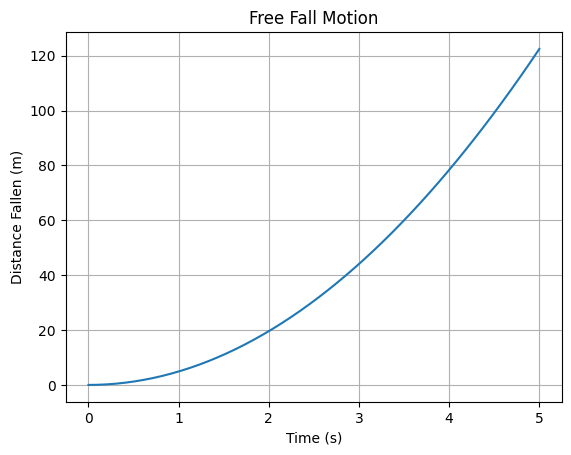

In [13]:
import matplotlib.pyplot as plt
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Distance Fallen (m)")
plt.title("Free Fall Motion")
plt.grid(True)
plt.show()

## 7. Ohm's Law
$V = IR$

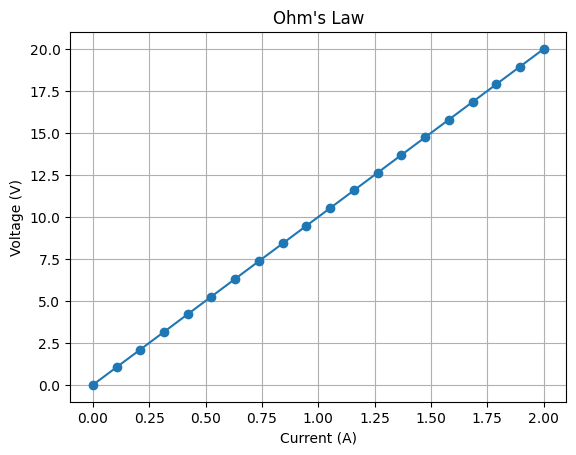

In [15]:
R = 10 # Ohms
I = np.linspace(0, 2, 20)
V = I * R
plt.plot(I, V, marker='o')
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Ohm's Law")
plt.grid(True)
plt.show()

## Exercise: Projectile Motion
The vertical position of a projectile is given by

$y = y_0 + v_0 t - \frac{1}{2}g t^2$

where $y_0$ is the initial vertical position, $v_0$ is the initial vertical speed and $g = 9.8$ m/s$^2$.

Make a plot of the vertical position of a projectile over time with $y_0 = 0$ m and $v_0 = 12.3$ m/s from launch until it returns to the initial height. Label the axes.

Text(0, 0.5, 'Vertical Position (m)')

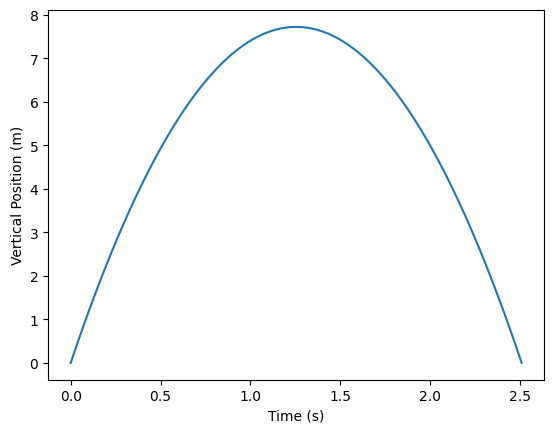

In [9]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.8 # m/s^2
v_0 = 12.3 # m/s
t = np.linspace(0.0, 2.51, 100)
y = v_0*t - 0.5*g*t**2

plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Vertical Position (m)")